In [13]:
%pip install dival --break-system-packages
%pip install tqdm --break-system-packages
%pip install matplotlib --break-system-packages

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import DataLoader

In [3]:
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print("Device:", device)

Device: cuda


In [4]:
from dival import get_standard_dataset

dataset = get_standard_dataset("lodopab", impl="skimage")

train_dataset = dataset.create_torch_dataset(part="train")
test_dataset = dataset.create_torch_dataset(part="test")
val_dataset = dataset.create_torch_dataset(part="validation")

In [5]:
batch_size = 16

train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True,
    num_workers=4,
    pin_memory=True,
)
val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)
test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False,
    num_workers=4,
    pin_memory=True,
)

In [ ]:
class UNetV2(nn.Module):
    def __init__(self):
        super().__init__()

        def conv_block(in_ch, out_ch):
            return nn.Sequential(
                nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
                nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1),
                nn.ReLU(inplace=True),
            )

        # Encoder (halved channels)
        self.enc1 = conv_block(1, 32)
        self.pool1 = nn.MaxPool2d(2)  # 1000x513 -> 500x256
        self.enc2 = conv_block(32, 64)
        self.pool2 = nn.MaxPool2d(2)  # 500x256 -> 250x128
        self.enc3 = conv_block(64, 128)
        self.pool3 = nn.MaxPool2d(2)  # 250x128 -> 125x64
        self.enc4 = conv_block(128, 256)

        # Bottleneck
        self.bottleneck = conv_block(256, 512)

        # Decoder (halved channels accordingly)
        self.up3 = nn.ConvTranspose2d(512, 256, kernel_size=2, stride=2)
        self.dec3 = conv_block(256 + 128, 256)

        self.up2 = nn.ConvTranspose2d(256, 128, kernel_size=2, stride=2)
        self.dec2 = conv_block(128 + 64, 128)

        self.up1 = nn.ConvTranspose2d(128, 64, kernel_size=2, stride=2)
        self.dec1 = conv_block(64 + 32, 64)

        self.final = nn.Conv2d(64, 1, kernel_size=1)

        # Resize output to 362x362
        self.resize = nn.AdaptiveAvgPool2d((362, 362))

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool1(e1))
        e3 = self.enc3(self.pool2(e2))
        e4 = self.enc4(self.pool3(e3))

        b = self.bottleneck(e4)

        d3 = self.up3(b)
        d3 = self.dec3(torch.cat([d3, e3], dim=1))

        d2 = self.up2(d3)
        d2 = self.dec2(torch.cat([d2, e2], dim=1))

        d1 = self.up1(d2)
        d1 = F.interpolate(d1, size=e1.shape[2:], mode="bilinear", align_corners=False)
        d1 = self.dec1(torch.cat([d1, e1], dim=1))

        out = self.final(d1)
        return self.resize(out)

In [7]:
model = UNetV2().to(device)

# Model size
print(sum(p.numel() for p in model.parameters() if p.requires_grad))

7336545


In [8]:
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.MSELoss()

In [9]:
import os


def save_state(epoch, model, optimizer):
    checkpoint_dir = "/workspace/checkpoints"
    os.makedirs(checkpoint_dir, exist_ok=True)

    checkpoint = {
        "epoch": epoch,
        "model_state_dict": model.state_dict(),
        "optimizer_state_dict": optimizer.state_dict(),
    }
    torch.save(checkpoint, f"{checkpoint_dir}/checkpoint_{epoch}.pt")

In [10]:
from tqdm import tqdm

epochs = 50
patience = 3

best_weights = None
best_loss = float("inf")
early_stopping_counter = 0

train_losses = []
val_losses = []

print("Training started")

for epoch in range(epochs):
    model.train()
    running_loss = 0.0

    # Training loop with progress bar
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs} [Train]", leave=False)
    for sino, img in train_bar:
        sino = sino.unsqueeze(1).to(device, non_blocking=True)  # [B, 1, H, W]
        img = img.unsqueeze(1).to(device, non_blocking=True)    # [B, 1, H, W]

        output = model(sino)
        loss = criterion(output, img)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        train_bar.set_postfix(loss=loss.item())
    
    running_loss /= len(train_loader)

    # Validation loop with progress bar
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        val_bar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{epochs} [Val]", leave=False)
        for sino, img in val_bar:
            sino = sino.unsqueeze(1).to(device, non_blocking=True)
            img = img.unsqueeze(1).to(device, non_blocking=True)

            output = model(sino)
            loss = criterion(output, img)
            val_loss += loss.item()
            val_bar.set_postfix(val_loss=loss.item())
        
    val_loss /= len(val_loader)

    # Save checkpoints every 5 epochs
    if epoch % 5 == 0:
        save_state(epoch, model, optimizer)

    # Check if this is the best model so far
    if val_loss < best_loss:
        best_loss = val_loss
        best_weights = model.state_dict()

    # Early stopping
    if val_loss > (1.01 * val_losses[-1] if val_losses else float("inf")):
        early_stopping_counter += 1

    if early_stopping_counter >= patience:
        print("Early stopping triggered")
        break

    train_losses.append(running_loss)
    val_losses.append(val_loss)

    print(
        f"Epoch {epoch+1}/{epochs} | "
        f"Train Loss: {running_loss:.4f} | "
        f"Val Loss: {val_loss:.4f}"
    )

Training started


Epoch 1/50 | Train Loss: 0.0272 | Val Loss: 0.0079


Epoch 2/50 | Train Loss: 0.0073 | Val Loss: 0.0063


Epoch 3/50 | Train Loss: 0.0062 | Val Loss: 0.0056


Epoch 4/50 | Train Loss: 0.0057 | Val Loss: 0.0052


...

Epoch 19/50 | Train Loss: 0.0038 | Val Loss: 0.0038


Epoch 20/50 | Train Loss: 0.0038 | Val Loss: 0.0038


Epoch 21/50 | Train Loss: 0.0038 | Val Loss: 0.0038


Epoch 22/50 | Train Loss: 0.0038 | Val Loss: 0.0038


KeyboardInterrupt: 

In [11]:
if best_weights is not None:
    model.load_state_dict(best_weights)
    print("Loaded best model weights with loss:", best_loss)

Loaded best model weights with loss: 0.0037701672029458156


In [12]:
# Test
test_loss = 0.0
model.eval()
with torch.no_grad():
    for sino, img in test_loader:
        sino = sino.unsqueeze(1).to(device, non_blocking=True)  # [B, 1, H, W]
        img = img.unsqueeze(1).to(device, non_blocking=True)    # [B, 1, H, W]

        output = model(sino)
        loss = criterion(output, img)
        test_loss += loss.item()

print(f"Test Loss: {test_loss / len(test_loader):.4f}")

Test Loss: 0.0042


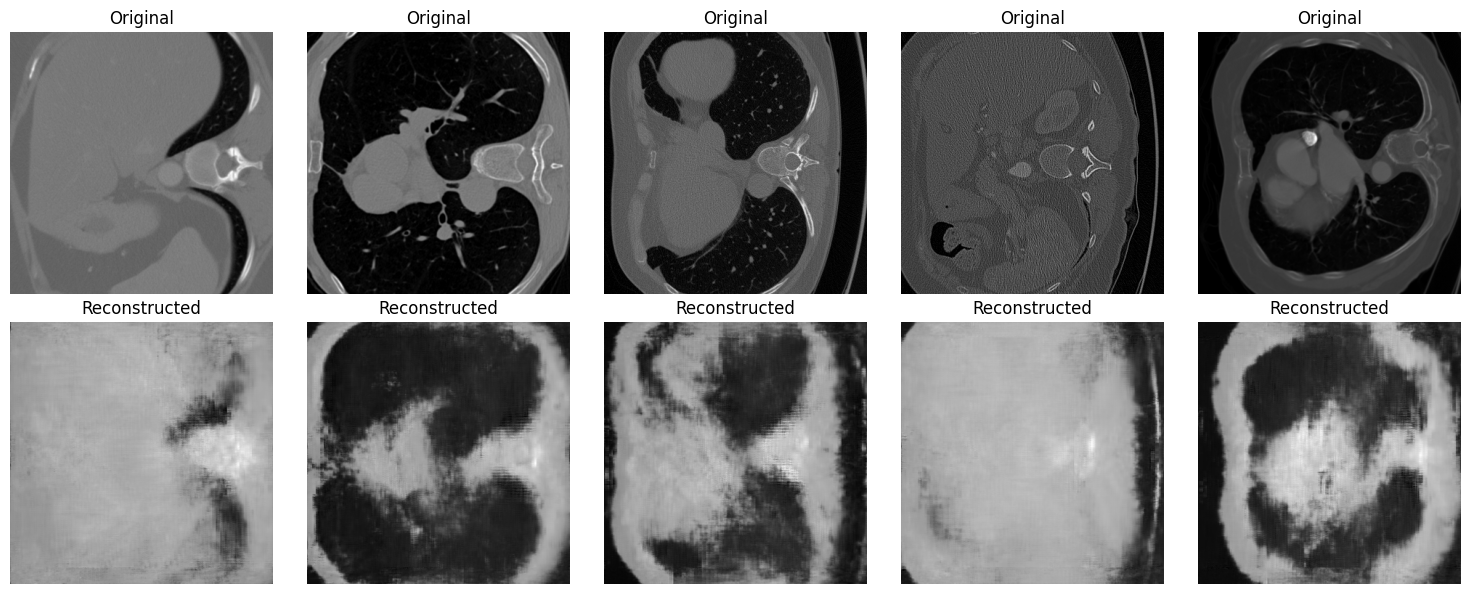

In [22]:
import matplotlib.pyplot as plt

def show_reconstructed_images(model, dataloader, device, num_images=5):
    model.eval()
    shown = 0
    with torch.no_grad():
        for sino, img in dataloader:
            sino = sino.unsqueeze(1).to(device, non_blocking=True)
            img = img.unsqueeze(1).to(device, non_blocking=True)

            output = model(sino)

            batch_size = img.size(0)
            n = min(batch_size, num_images - shown)

            # Create a figure with 2 rows: original and reconstructed
            fig, axes = plt.subplots(nrows=2, ncols=n, figsize=(3 * n, 6))

            for i in range(n):
                # Original image
                axes[0, i].imshow(img[i].cpu().numpy().squeeze(), cmap="gray")
                axes[0, i].set_title("Original")
                axes[0, i].axis("off")

                # Reconstructed image
                axes[1, i].imshow(output[i].cpu().numpy().squeeze(), cmap="gray")
                axes[1, i].set_title("Reconstructed")
                axes[1, i].axis("off")

            plt.tight_layout()
            plt.show()

            shown += n
            if shown >= num_images:
                break

show_reconstructed_images(model, test_loader, device, num_images=5)

In [23]:
# Save the model
model_name = "362x362_2908_unetv2.pth"
model_directory = "/workspace/models"
model_path = f"{model_directory}/{model_name}"

os.makedirs(model_directory, exist_ok=True)

if os.path.exists(model_path):
    print(f"Model {model_name} already exists.")
else:
    print(f"Saving model to {model_path}")
    torch.save(model.state_dict(), model_path)

Saving model to /workspace/models/362x362_2908_unetv2.pth
